In [176]:
#Inference Evaluation Script
from Single_ag_Environment import SingleSatelliteEnv
from gymnasium.utils.env_checker import check_env
import traceback
import numpy as np
import gymnasium as gym
import torch
print(type(SingleSatelliteEnv))
# This will catch many common issues
env = SingleSatelliteEnv(render_mode="None")
try:
    check_env(env)
    print("Environment passes all checks!")
except Exception as e:
    print("Environment has issues:")
    traceback.print_exc()
from cleanrl.cleanrl.dqn import QNetwork
from cleanrl.cleanrl.c51 import QNetwork as C51Network
from cleanrl.cleanrl.ppo import Agent
env =SingleSatelliteEnv(render_mode="None")
envs = gym.vector.SyncVectorEnv([
    lambda: SingleSatelliteEnv(render_mode="None")
])


<class 'type'>
Environment passes all checks!


/home/ethan/Documents/Research/Single_Agent_EO_Project/CleanAgvenv/lib/python3.10/site-packages/gymnasium/utils/env_checker.py:321: UserWarning: WARN: Not able to test alternative render modes due to the environment not having a spec. Try instantialising the environment through gymnasium.make
  logger.warn(


In [177]:
#C51

def C51_test(Testing_seed_Configuration,num_of_test_episodes,num_of_models):
    envs = gym.vector.SyncVectorEnv([
        lambda: SingleSatelliteEnv(render_mode="None")
    ])
    #Put the output vectors here for the tests
    vector_index=0
    C51_reward_vector=np.zeros([len(Testing_seed_Configuration)*num_of_test_episodes*num_of_models,])
    C51_delivery_ratio_vector=np.zeros([len(Testing_seed_Configuration)*num_of_test_episodes*num_of_models,])
    C51_mean_contact_energy_efficiency_vector=np.zeros([len(Testing_seed_Configuration)*num_of_test_episodes*num_of_models,])
    #Next we are going to import from 
    

    
    for i in range(0,len(Testing_seed_Configuration)):
        envs.reset(seed=Testing_seed_Configuration[i])
        for j in range(0,num_of_test_episodes):
            for k in range(0,num_of_models):
                obs, _ = envs.reset()
                
                model = C51Network(envs).to("cpu")
                
                # Load trained weights
                checkpoint = torch.load("Models/C51/c51_"+str(k)+".cleanrl_model")
                #print(checkpoint)
                model.load_state_dict(checkpoint["model_weights"]) #CleanRL saves weights under "model"
                #print(dir(model))
                # Inference loop
                done = False
                total_reward=0
                while not done:
                    obs_tensor = torch.tensor(obs, dtype=torch.float32)
                    with torch.no_grad():
                        action, q_values = model.get_action(obs_tensor)
                        #print("C51 action")
                        #print(action)
                        action=int(action)
                        #print(action)
                    obs, reward, terminated, truncated, info = envs.step([action])
                    #print(info)
                    total_reward+=reward
                    done = terminated or truncated
                
                final_info=info['final_info'][0]
                #print(final_info)
                initial_data_volume=final_info['Initial Data']
                #print("c51 initial data")
                #print(initial_data_volume)
                delivered_packets=final_info['Delivered Data']
                #print("c51 delivered_packets")
                #print(delivered_packets)
                number_of_contacts=final_info['Number of Contacts']
                excess_energy_expended=final_info['Energy Expended']
                C51_reward_vector[vector_index]=total_reward
                C51_delivery_ratio_vector[vector_index]=delivered_packets/(initial_data_volume*100)
                C51_mean_contact_energy_efficiency_vector[vector_index]=delivered_packets/(number_of_contacts*10)
    
                vector_index+=1
                envs.close()
    return C51_reward_vector,C51_delivery_ratio_vector,C51_mean_contact_energy_efficiency_vector
            


In [178]:
#DQN
def DQN_test(Testing_seed_Configuration,num_of_test_episodes,num_of_models):
    envs = gym.vector.SyncVectorEnv([
        lambda: SingleSatelliteEnv(render_mode="None")
    ])
    DQN_reward_vector=np.zeros([len(Testing_seed_Configuration)*num_of_test_episodes*num_of_models,])
    DQN_delivery_ratio_vector=np.zeros([len(Testing_seed_Configuration)*num_of_test_episodes*num_of_models,])
    DQN_mean_contact_energy_efficiency_vector=np.zeros([len(Testing_seed_Configuration)*num_of_test_episodes*num_of_models,])
    vector_index=0
    for i in range(0,5):
        envs.reset(seed=Testing_seed_Configuration[i])
        for j in range(0,num_of_test_episodes):
            for k in range(0,num_of_models):
                obs, _ = envs.reset(seed=Testing_seed_Configuration[i])
                
                model = QNetwork(envs).to("cpu")
                
                # Load trained weights
                checkpoint = torch.load("Models/DQN/dqn_"+str(k)+".cleanrl_model")
                #print(checkpoint)
                model.load_state_dict(checkpoint) #CleanRL saves weights under "model"
                #print(dir(model))
                # Inference loop
                done = False
                while not done:
                    obs_tensor = torch.tensor(obs, dtype=torch.float32)
                    with torch.no_grad():
                        q_values = model(torch.Tensor(obs).to("cpu"))
                        action= torch.argmax(q_values, dim=1).cpu().numpy()
                        #print("DQN action")
                        #print(action)
                        
                    obs, reward, terminated, truncated, info = envs.step(action)
                    done = terminated or truncated
                final_info=info['final_info'][0]
                initial_data_volume=final_info["Initial Data"]
                delivered_packets=final_info["Delivered Data"]
                number_of_contacts=final_info["Number of Contacts"]
                excess_energy_expended=final_info["Energy Expended"]
                DQN_reward_vector[vector_index]=total_reward
                DQN_delivery_ratio_vector[vector_index]=delivered_packets/(initial_data_volume*100)
                DQN_mean_contact_energy_efficiency_vector[vector_index]=delivered_packets/(number_of_contacts*10)
                vector_index+=1
                envs.close()
    return DQN_reward_vector,DQN_delivery_ratio_vector,DQN_mean_contact_energy_efficiency_vector
            

In [179]:
#PPO
# Load environment

def PPO_test(Testing_seed_Configuration,num_of_test_episodes,num_of_models):
    envs = gym.vector.SyncVectorEnv([
        lambda: SingleSatelliteEnv(render_mode="None")
    ])
   
    PPO_reward_vector=np.zeros([len(Testing_seed_Configuration)*num_of_test_episodes*num_of_models,])
    PPO_delivery_ratio_vector=np.zeros([len(Testing_seed_Configuration)*num_of_test_episodes*num_of_models,])
    PPO_mean_contact_energy_efficiency_vector=np.zeros([len(Testing_seed_Configuration)*num_of_test_episodes*num_of_models,])
    vector_index=0
    for i in range(0,len(Testing_seed_Configuration)):
        envs.reset(seed=Testing_seed_Configuration[i])
        for j in range(0,num_of_test_episodes):
            for k in range(0,num_of_models):
                obs, _ = envs.reset()
                agent = Agent(envs).to("cpu")
                
                # Load trained weights
                checkpoint = torch.load("Models/PPO/ppo_"+str(k)+".cleanrl_model")
                #print(checkpoint)
                agent.load_state_dict(checkpoint["model"])   # CleanRL saves weights under "model"
                
                # Inference loop
                done = False
                while not done:
                    obs_tensor = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)
                    with torch.no_grad():
                        action, _, _,qvalue = agent.get_action_and_value(obs_tensor)
                        #print("PPO action")
                        #print(action)
                        #action.cpu().numpy()
                    obs, reward, terminated, truncated, info = envs.step(action)
                    done = terminated or truncated
                final_info=info['final_info'][0]
                initial_data_volume=final_info["Initial Data"]
                delivered_packets=final_info["Delivered Data"]
                number_of_contacts=final_info["Number of Contacts"]
                excess_energy_expended=final_info["Energy Expended"]
                PPO_reward_vector[vector_index]=total_reward
                PPO_delivery_ratio_vector[vector_index]=delivered_packets/(initial_data_volume*100)
                PPO_mean_contact_energy_efficiency_vector[vector_index]=delivered_packets/(number_of_contacts*10)
                vector_index+=1
                envs.close()
    return PPO_reward_vector,PPO_delivery_ratio_vector,PPO_mean_contact_energy_efficiency_vector

In [180]:
#Baseline ALgorithms
def BaselineCGR(env):
    
    init_observation,init_info=env.reset()
    #print(init_observation)
    delivery_ratio_metric=None
    contact_energy_efficiency=None
    total_reward=0
    done=False
    while not done:
        action = 1
        obs, reward, terminated, truncated, info = env.step(action)
        #print(action)
        done = terminated or truncated
        total_reward += reward
    #Next we need to extract final info from the episode
    initial_data_volume=info["Initial Data"]
    #print("CGR")
    #print("Initial Data Volume")
    #print(initial_data_volume)
    delivered_packets=info["Delivered Data"]
    #print(delivered_packets)
    number_of_contacts=info["Number of Contacts"]
    excess_energy_expended=info["Energy Expended"]
    #if((initial_data_volume*100)<delivered_packets):
        #print("Delivery ratio error")
    env.close()
    return total_reward,initial_data_volume,delivered_packets,number_of_contacts,excess_energy_expended
    

In [181]:
#Next we conduct training for the baseline CGR function
Number_of_Episodes=100
seeds=[50,51,52,53,54]
CGR_reward_vector=np.zeros([len(seeds)*Number_of_Episodes,])
CGR_delivery_ratio_vector=np.zeros([len(seeds)*Number_of_Episodes,])
CGR_mean_contact_energy_efficiency_vector=np.zeros([len(seeds)*Number_of_Episodes,])
vector_index=0
for h in range(0,Number_of_Episodes):
        for b in seeds:
            env.reset(b)
            total_reward,initial_data_volume,delivered_packets,number_of_contacts,excess_energy_expended=BaselineCGR(env)
          
            CGR_reward_vector[vector_index]=total_reward
            CGR_delivery_ratio_vector[vector_index]=delivered_packets/(initial_data_volume*100)
            CGR_mean_contact_energy_efficiency_vector[vector_index]=delivered_packets/(number_of_contacts*10)
            vector_index+=1
#Next we must make box plots these results

C51_tr,C51_dr,C51_ec=C51_test(seeds,100,5)
DQN_tr,DQN_dr,DQN_ec=DQN_test(seeds,100,5)
PPO_tr,PPO_dr,PPO_ec=PPO_test(seeds,100,5)


/tmp/ipykernel_2602177/1447364508.py:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("Models/C51/c51_"+str(k)+".cleanrl_model")
/tmp/ipykernel_2602

[2.55044365 2.55044365 2.55044365 ... 2.55044365 2.55044365 2.55044365]
[2.55044365 2.55044365 2.55044365 ... 2.55044365 2.55044365 2.55044365]
[  2.13904179 -40.53309848  16.09135232 ...   4.23816286  17.22189053
 -18.19139378]
[0.54081632 0.99999996 1.00000002 ... 0.73913044 1.00000001 0.99999996]


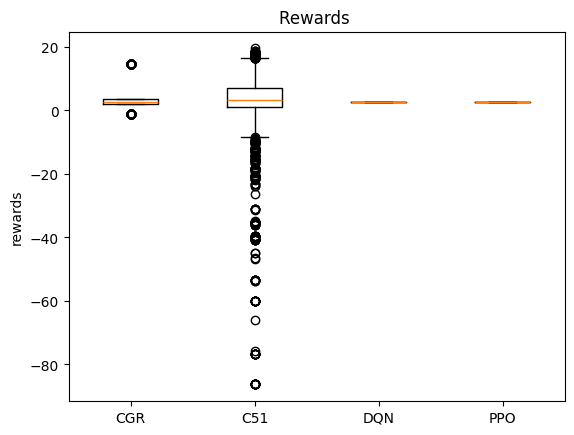

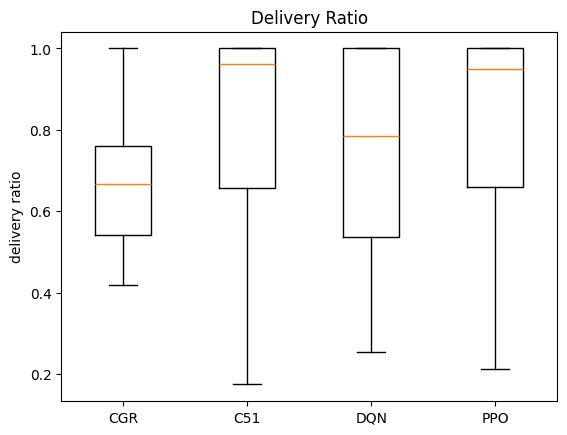

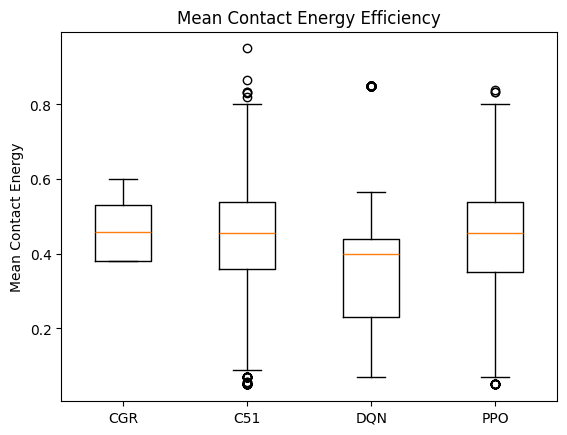

In [182]:
#Output the graphs
import matplotlib.pyplot as plt
print(PPO_tr)
print(DQN_tr)
print(C51_tr)
print(C51_dr)
plt.boxplot([CGR_reward_vector,C51_tr,DQN_tr,PPO_tr], tick_labels=['CGR','C51','DQN', 'PPO'])
plt.title("Rewards ")
plt.ylabel("rewards")
plt.show()
#Delivery Ratio Plot
plt.boxplot([CGR_delivery_ratio_vector, C51_dr,DQN_dr,PPO_dr], tick_labels=['CGR', 'C51','DQN','PPO'])

plt.title("Delivery Ratio")
plt.ylabel("delivery ratio")
plt.show()
#Contact Energy Efficiency Plot
plt.boxplot([CGR_mean_contact_energy_efficiency_vector, C51_ec,DQN_ec,PPO_ec], tick_labels=['CGR', 'C51','DQN','PPO'])

plt.title("Mean Contact Energy Efficiency")
plt.ylabel("Mean Contact Energy")
plt.show()